# 03 — Exploratory Data Analysis

Profiling (`01_profiling.ipynb`) described the data's structure and
validity. Cleaning (`02_cleaning.ipynb`) fixed two specific bugs it
found. This notebook does the job profiling deliberately stayed away
from: looking for relationships — with the target, between
predictors, and across time — because those relationships are what
the rest of the project's decisions rest on.

Three questions this notebook exists to answer, in order of how much
they change downstream decisions:

1. **Does `posted_rate` drift or show seasonality across the year?**
   This is the single most consequential question here — its answer
   is what justifies (or undercuts) the chronological train/tune/test
   split agreed on in the roadmap, and sets where the cutoffs go.
2. **What actually predicts `posted_rate`?** Distance, equipment,
   the two market-condition signals — a correlation matrix plus
   targeted scatter/box plots, so feature engineering isn't guessing.
3. **What does `posted_rate` itself look like?** Skew, tails, whether
   a log-transform is worth carrying into modeling.

All charts use `src/viz.py`, styled to match Spotter's own market
intelligence dashboard.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

from src import config, data, viz

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
viz.apply_theme()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

STAGE = "eda"

INFO src.viz: Applied Spotter brand theme to matplotlib rcParams


## Load the cleaned data

Reading from `data/processed/`, the output of `02_cleaning.ipynb` —
sign-flip and fallback-distance fixes already applied, `date` already
a real datetime. `weight` and `market_index` still carry their
original missing values on purpose; imputation is a pipeline concern,
not resolved by the time EDA runs.

In [2]:
train_test = data.load_train_test_cleaned()
train_test["date"] = pd.to_datetime(train_test["date"])
train_test.shape

INFO src.data: Loading C:\dev\Spotter-ML-Engineer-Assessment\data\processed\train_test.csv
INFO src.data: Loaded train_test.csv: 48000 rows, 14 columns


(48000, 14)

## 1. Drift and seasonality across the year

`train_test` spans 2025-01-01 to 2025-10-31; `validation` picks up
immediately after, 2025-11-01 to 2025-12-31 — confirmed in profiling,
zero overlap. The question here isn't *whether* to split
chronologically (that already follows from the date ranges alone) —
it's *how much* the rate distribution actually moves across the
months we can observe, since that's what decides where the
train/tune/test cutoffs go and how much to trust a single held-out
month as representative.

In [3]:
monthly = train_test.groupby(train_test["date"].dt.to_period("M"))["posted_rate"].agg(
    ["mean", "median", "std", "count"]
)
monthly.index = monthly.index.astype(str)
monthly

,mean,median,std,count
date,,,,
2025-01,2255.967048,1915.200,1454.274952,4918
2025-02,2273.804801,1994.250,1317.077105,4337
2025-03,2372.268092,2022.920,1462.531615,5036
2025-04,2372.162308,2044.240,1463.102457,4819
2025-05,2421.776342,2065.510,1486.071436,4913
2025-06,2497.030115,2120.220,1606.707302,4783
2025-07,2415.162030,2059.145,1504.943296,4912
2025-08,2338.407661,2015.730,1474.979672,4759
2025-09,2406.374013,2057.130,1523.483983,4670


INFO src.viz: Plotting trend line: Mean posted_rate by month, Jan-Oct 2025 (n=10)
INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO matplotlib.category: Using categorical units to p

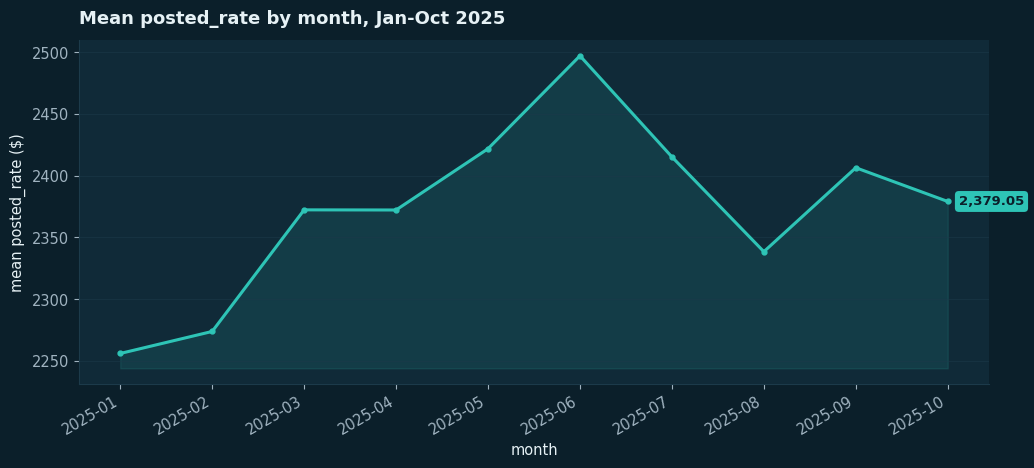

In [4]:
fig = viz.plot_trend_line(
    x=monthly.index,
    y=monthly["mean"],
    stage=STAGE,
    filename="monthly_mean_posted_rate.png",
    title="Mean posted_rate by month, Jan-Oct 2025",
    xlabel="month",
    ylabel="mean posted_rate ($)",
)

Monthly mean rate moves from $2,256 in January up to a $2,497 peak in
June, then eases back down to $2,379 by October. That's a real but
modest swing — about 10% peak-to-trough — not a runaway trend in
either direction. Useful calibration for how much to trust October
(the month that will sit in the final held-out test slice) as
representative: October's mean ($2,379) sits almost exactly on the
January-through-July average ($2,373), so whatever is moving the
rate isn't drifting the series somewhere new and unrecognizable by
the end of the window we can observe — it's a seasonal wobble, not
instability. Standard deviation also grows alongside the mean through
the summer months (std peaks in June at 1,607, same month as the mean
peak) — worth carrying into modeling as "the summer months are both
higher-rate and higher-variance," not two separate facts.

**What this means for the split:** a chronological split is
defensible not just because the date ranges don't overlap (that part
was already settled in profiling) but because the drift itself is
real enough that evaluating on a randomly-shuffled fold would give an
optimistic picture of how the model handles a genuinely different
month. October, the latest month available, is the most honest single
month to reserve as the untouched final test slice, since it's the
closest analog in the data to what `validation.csv`'s November
actually looks like.

## 2. What predicts `posted_rate`?

### 2a. Correlation matrix — general picture first

In [5]:
numeric_cols = ["distance", "weight", "market_index", "quote_signal", "posted_rate"]
corr = train_test[numeric_cols].corr()
corr.round(4)

,distance,weight,market_index,quote_signal,posted_rate
distance,1.0000,0.0019,-0.0022,-0.0573,0.9085
weight,0.0019,1.0000,0.0027,0.0061,0.0413
market_index,-0.0022,0.0027,1.0000,-0.0678,0.0342
quote_signal,-0.0573,0.0061,-0.0678,1.0000,-0.0399
posted_rate,0.9085,0.0413,0.0342,-0.0399,1.0000


INFO src.viz: Plotting correlation heatmap: Correlation matrix -- numeric columns (5 x 5)


INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\eda\correlation_matrix.png


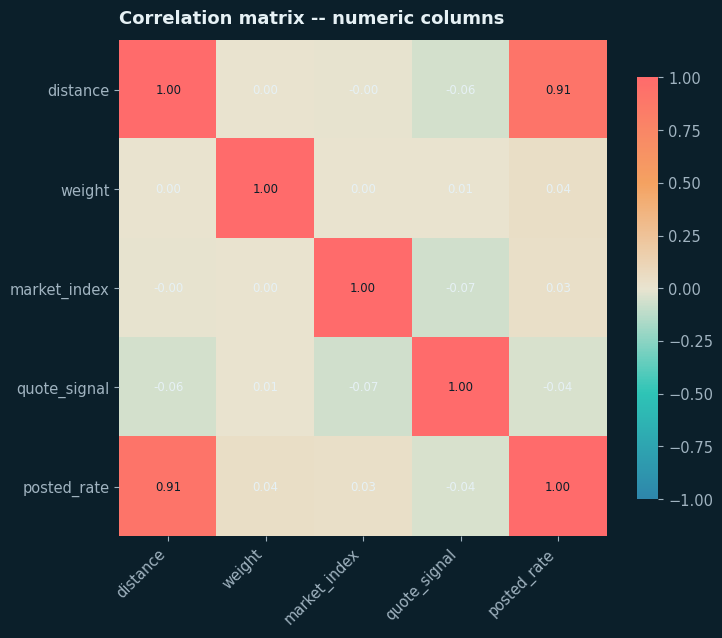

In [6]:
fig = viz.plot_correlation_heatmap(
    corr,
    stage=STAGE,
    filename="correlation_matrix.png",
    title="Correlation matrix -- numeric columns",
)

One relationship dominates: `distance` correlates with `posted_rate`
at 0.91 — by far the strongest signal in the dataset. Everything else
is weak in a straight-line sense: `weight` (0.04), `market_index`
(0.03), `quote_signal` (-0.04) — none of these clear even 0.05
correlation with the target. That doesn't mean they're useless (a
correlation coefficient only catches linear relationships — a tree
model could still find a real non-linear interaction, e.g.
`market_index` mattering more specifically for long-haul loads), but
it's a first, honest read: distance is carrying almost all of the
straight-line explanatory power here.

This has a direct bearing on the December fork agreed on in the
roadmap: December's file is missing `market_index` and `quote_signal`
entirely. If those columns aren't strongly (linearly) related to the
target even in the full data, the accuracy cost of the reduced
December model not having them is probably small — this is empirical
support for that decision, not just a structural argument about what
columns exist where.

### 2b. Rate vs. distance directly

INFO src.viz: Plotting scatter: posted_rate vs. distance (6,000-row sample) (n=6000)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\eda\rate_vs_distance.png


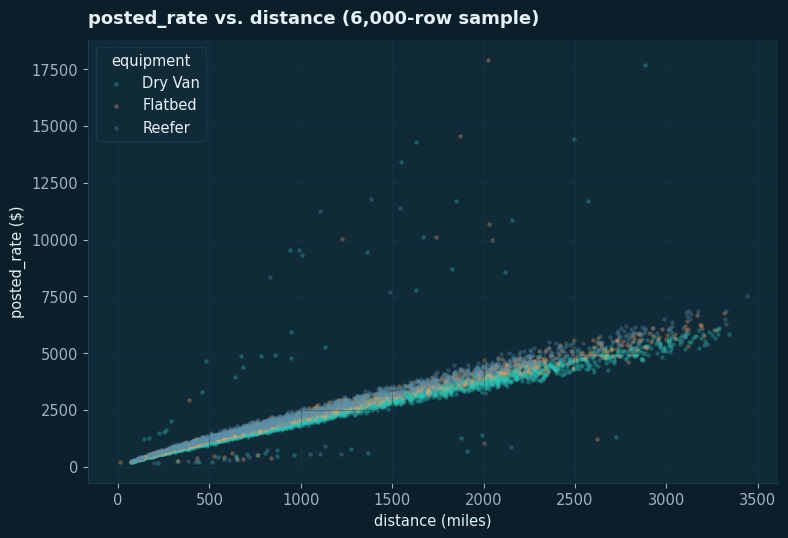

In [7]:
sample = train_test.sample(n=6000, random_state=42)
fig = viz.plot_scatter(
    x=sample["distance"],
    y=sample["posted_rate"],
    stage=STAGE,
    filename="rate_vs_distance.png",
    title="posted_rate vs. distance (6,000-row sample)",
    xlabel="distance (miles)",
    ylabel="posted_rate ($)",
    hue=sample["equipment"],
    hue_label="equipment",
)

The relationship is close to linear with visibly increasing spread as
distance grows (rates for a 3,000-mile haul vary far more in absolute
dollar terms than rates for a 300-mile haul) — the kind of pattern
that often means the *relative* error is more stable than the
absolute error, which is a point in favor of also checking
rate-per-mile and/or a log-transformed target during modeling.
Equipment type visibly shifts the cloud (Reefer sits a bit above Dry
Van at the same distance) without changing the overall linear shape —
consistent with equipment being a real, additive driver rather than
something that changes the distance relationship's shape.

### 2c. Rate by equipment type

In [8]:
rate_per_mile = train_test["posted_rate"] / train_test["distance"]
by_equipment = train_test.assign(rate_per_mile=rate_per_mile).groupby("equipment")["rate_per_mile"].agg(
    ["mean", "median", "count"]
)
by_equipment.round(3)

,mean,median,count
equipment,,,
Dry Van,2.121,2.046,27202
Flatbed,2.306,2.220,8753
Reefer,2.386,2.312,12045


INFO src.viz: Plotting grouped box: posted_rate by equipment (3 groups)


INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\eda\posted_rate_by_equipment.png


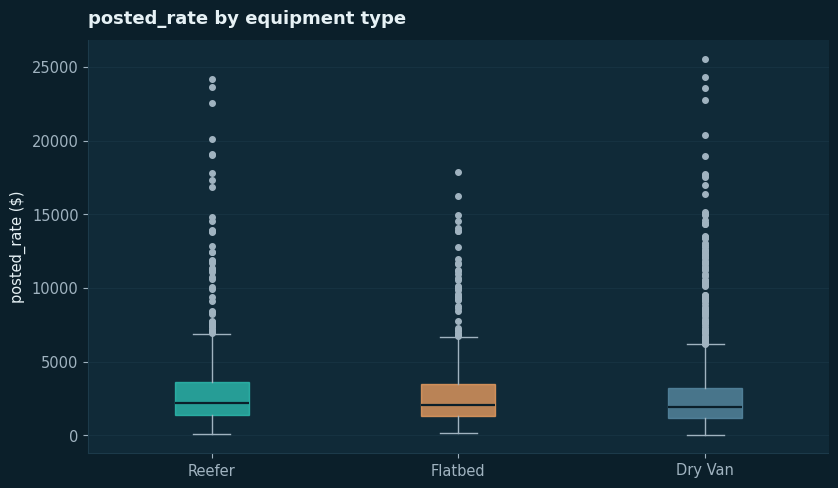

In [9]:
fig = viz.plot_grouped_box(
    train_test,
    group_col="equipment",
    value_col="posted_rate",
    stage=STAGE,
    filename="posted_rate_by_equipment.png",
    title="posted_rate by equipment type",
    ylabel="posted_rate ($)",
)

A clean, sensible ordering: Dry Van runs cheapest per mile ($2.12),
Flatbed in the middle ($2.31), Reefer most expensive ($2.39) — matches
real-world intuition (refrigeration adds cost, flatbed handles more
specialized freight than dry van) rather than looking arbitrary.
Equipment type is a legitimate categorical predictor worth encoding
properly in feature engineering, not a candidate to drop.

### 2d. Market-condition signals vs. rate

`market_index` and `quote_signal` both correlate weakly with
`posted_rate` in the matrix above (0.03 and -0.04). Worth looking at
directly rather than trusting the coefficient alone, since these are
exactly the two columns December's file is missing.

INFO src.viz: Plotting scatter: posted_rate vs. market_index (6,000-row sample) (n=6000)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\eda\rate_vs_market_index.png


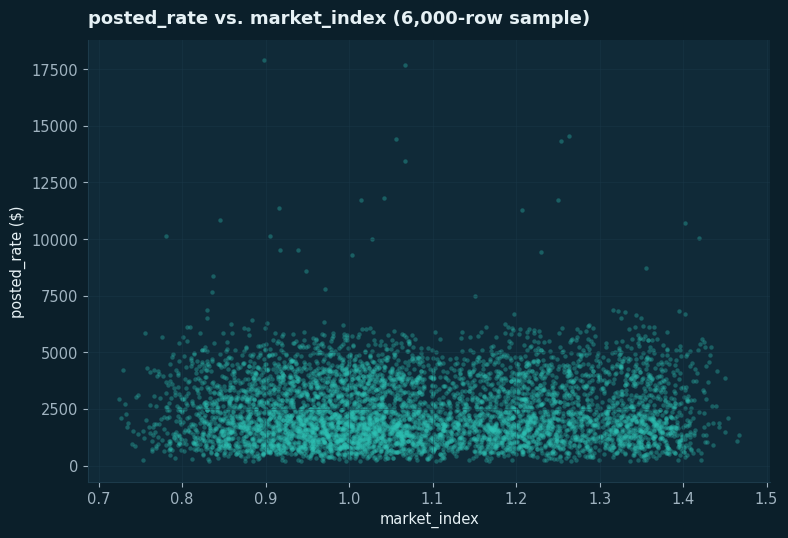

In [10]:
fig = viz.plot_scatter(
    x=sample["market_index"],
    y=sample["posted_rate"],
    stage=STAGE,
    filename="rate_vs_market_index.png",
    title="posted_rate vs. market_index (6,000-row sample)",
    xlabel="market_index",
    ylabel="posted_rate ($)",
)

No visible linear or obviously non-linear trend — the cloud is
essentially flat across the full range of `market_index`, consistent
with the near-zero correlation. This reinforces the read from the
correlation matrix: `market_index` isn't a strong standalone driver
of `posted_rate` in this data, at least not in a way a simple scatter
reveals. It may still interact with other features (e.g. matter more
for certain lanes or equipment types) — that's a feature-engineering
question, not resolved by a single 2D plot — but as a lone predictor
it looks weak, further support for the reduced December model not
giving up much by excluding it.

## 3. Shape of the target distribution

The last question profiling deliberately deferred: is `posted_rate`
skewed enough that a log-transform is worth carrying into modeling?

In [11]:
print("posted_rate skew:", round(train_test["posted_rate"].skew(), 4))
print("log(posted_rate) skew:", round(np.log(train_test["posted_rate"]).skew(), 4))

posted_rate skew: 1.9024
log(posted_rate) skew: -0.4906


INFO src.viz: Plotting histogram: posted_rate: raw vs. log-transformed (n=48000)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\eda\posted_rate_distribution.png


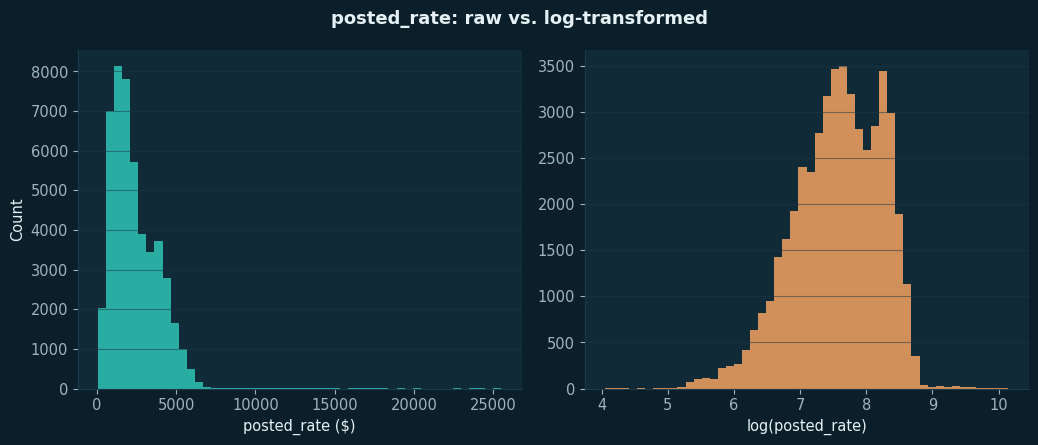

In [12]:
fig = viz.plot_histogram(
    train_test["posted_rate"],
    stage=STAGE,
    filename="posted_rate_distribution.png",
    title="posted_rate: raw vs. log-transformed",
    xlabel="posted_rate ($)",
    log_series=np.log(train_test["posted_rate"]),
    log_label="log(posted_rate)",
)

Raw `posted_rate` is right-skewed (skew = 1.90) — a long tail of
expensive, mostly long-haul loads pulling the distribution out to the
right, visible in the left panel. `log(posted_rate)` brings that down
to -0.49 and looks close to symmetric in the right panel — real,
concrete support for testing a log-transformed target during
modeling, not just a hunch. Whether it actually improves the model
(versus, say, a tree-based model that doesn't care about target
symmetry the way a linear model does) is a modeling-phase question —
this just establishes that the raw target's shape makes it worth
testing.

## 4. A closer look at the top outliers

The August-conversation flagged a handful of $23k-25k rates as worth
a specific look, rather than writing them off from a summary
statistic alone.

In [13]:
train_test.nlargest(8, "posted_rate")[["load_id", "pickup", "delivery", "distance", "equipment", "posted_rate"]]

,load_id,pickup,delivery,distance,equipment,posted_rate
12184,TR-012185,Bakersfield,Hartford,2829.8,Dry Van,25533.00
37764,TR-037765,Phoenix,Syracuse,2810.9,Dry Van,24294.98
1466,TR-001467,Los Angeles,Syracuse,2786.0,Reefer,24140.21
17371,TR-017372,Reno,Philadelphia,2777.6,Reefer,23662.71
26235,TR-026236,Charleston,Phoenix,2552.5,Dry Van,23580.42
28219,TR-028220,Tucson,Raleigh,2423.3,Dry Van,22755.66
3353,TR-003354,Phoenix,Charleston,2527.9,Reefer,22534.65
40171,TR-040172,Montgomery,Fresno,2283.4,Dry Van,20361.89


Every one of the highest-rate loads is a genuine long-haul lane
(2,283-2,830 miles) — Bakersfield→Hartford, Phoenix→Syracuse,
LA→Syracuse, and so on. These read as real premium long-haul loads,
not data entry errors: the distances are plausible, and rate-per-mile
for these rows (roughly $8-9/mile) is high but not absurd for the
longest hauls in the dataset when overall rate-per-mile averages
$2.22 with a max of $27 (driven by very short, low-distance loads
where a flat minimum charge dominates the per-mile math, the opposite
outlier pattern from these long-haul rows). No cleaning action
indicated — flagging this as a real, explainable pattern for the
report rather than an unresolved anomaly.

## Summary

**Drift and seasonality** — Monthly mean `posted_rate` swings from
$2,256 (January) up to $2,497 (June) and back to $2,379 (October) —
a real but modest ~10% seasonal wobble. October's mean sits almost
exactly on the Jan-Jul average, so the series isn't running away
anywhere new by the end of the observable window. → Confirms the
chronological split isn't just structurally required (from profiling)
but empirically justified — the drift is real enough that a random
shuffle would overstate generalization, and October is a reasonable,
representative choice for the final untouched test slice.

**What predicts the target** — `distance` dominates (correlation
0.91); `weight`, `market_index`, and `quote_signal` are all weak in a
linear sense (all under 0.05). Equipment type shows a clean, sensible
ordering in rate-per-mile (Dry Van $2.12 < Flatbed $2.31 < Reefer
$2.39) and is a legitimate categorical predictor. `market_index`
shows no visible trend against `posted_rate` even directly plotted. →
Empirical support (not just a structural argument) for the two-model
December fork already agreed in the roadmap: the columns December is
missing aren't carrying much of the target's linear signal to begin
with.

**Target shape** — `posted_rate` is right-skewed (1.90); log-transform
brings that to -0.49, close to symmetric. → Worth testing a
log-transformed target during modeling, particularly for any
linear/distance-based model in the comparison.

**Outliers** — the highest-rate rows are all real long-haul lanes
with plausible rate-per-mile figures, not data errors. No cleaning
action needed.

**Carried into `04_feature_engineering.ipynb` and modeling:**
1. Chronological split: train on Jan-Jul, tune on Aug-Sep, final test
   on Oct — cutoffs chosen with actual monthly figures now in hand,
   not guessed.
2. `distance` and `equipment` are the two established, strong
   predictors to build around first.
3. Test a log-transformed target in the baseline and subsequent
   models.
4. `market_index`/`quote_signal` are weak solo predictors; worth
   revisiting only if a tree-based model's feature importance later
   disagrees with this linear read.